In [15]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


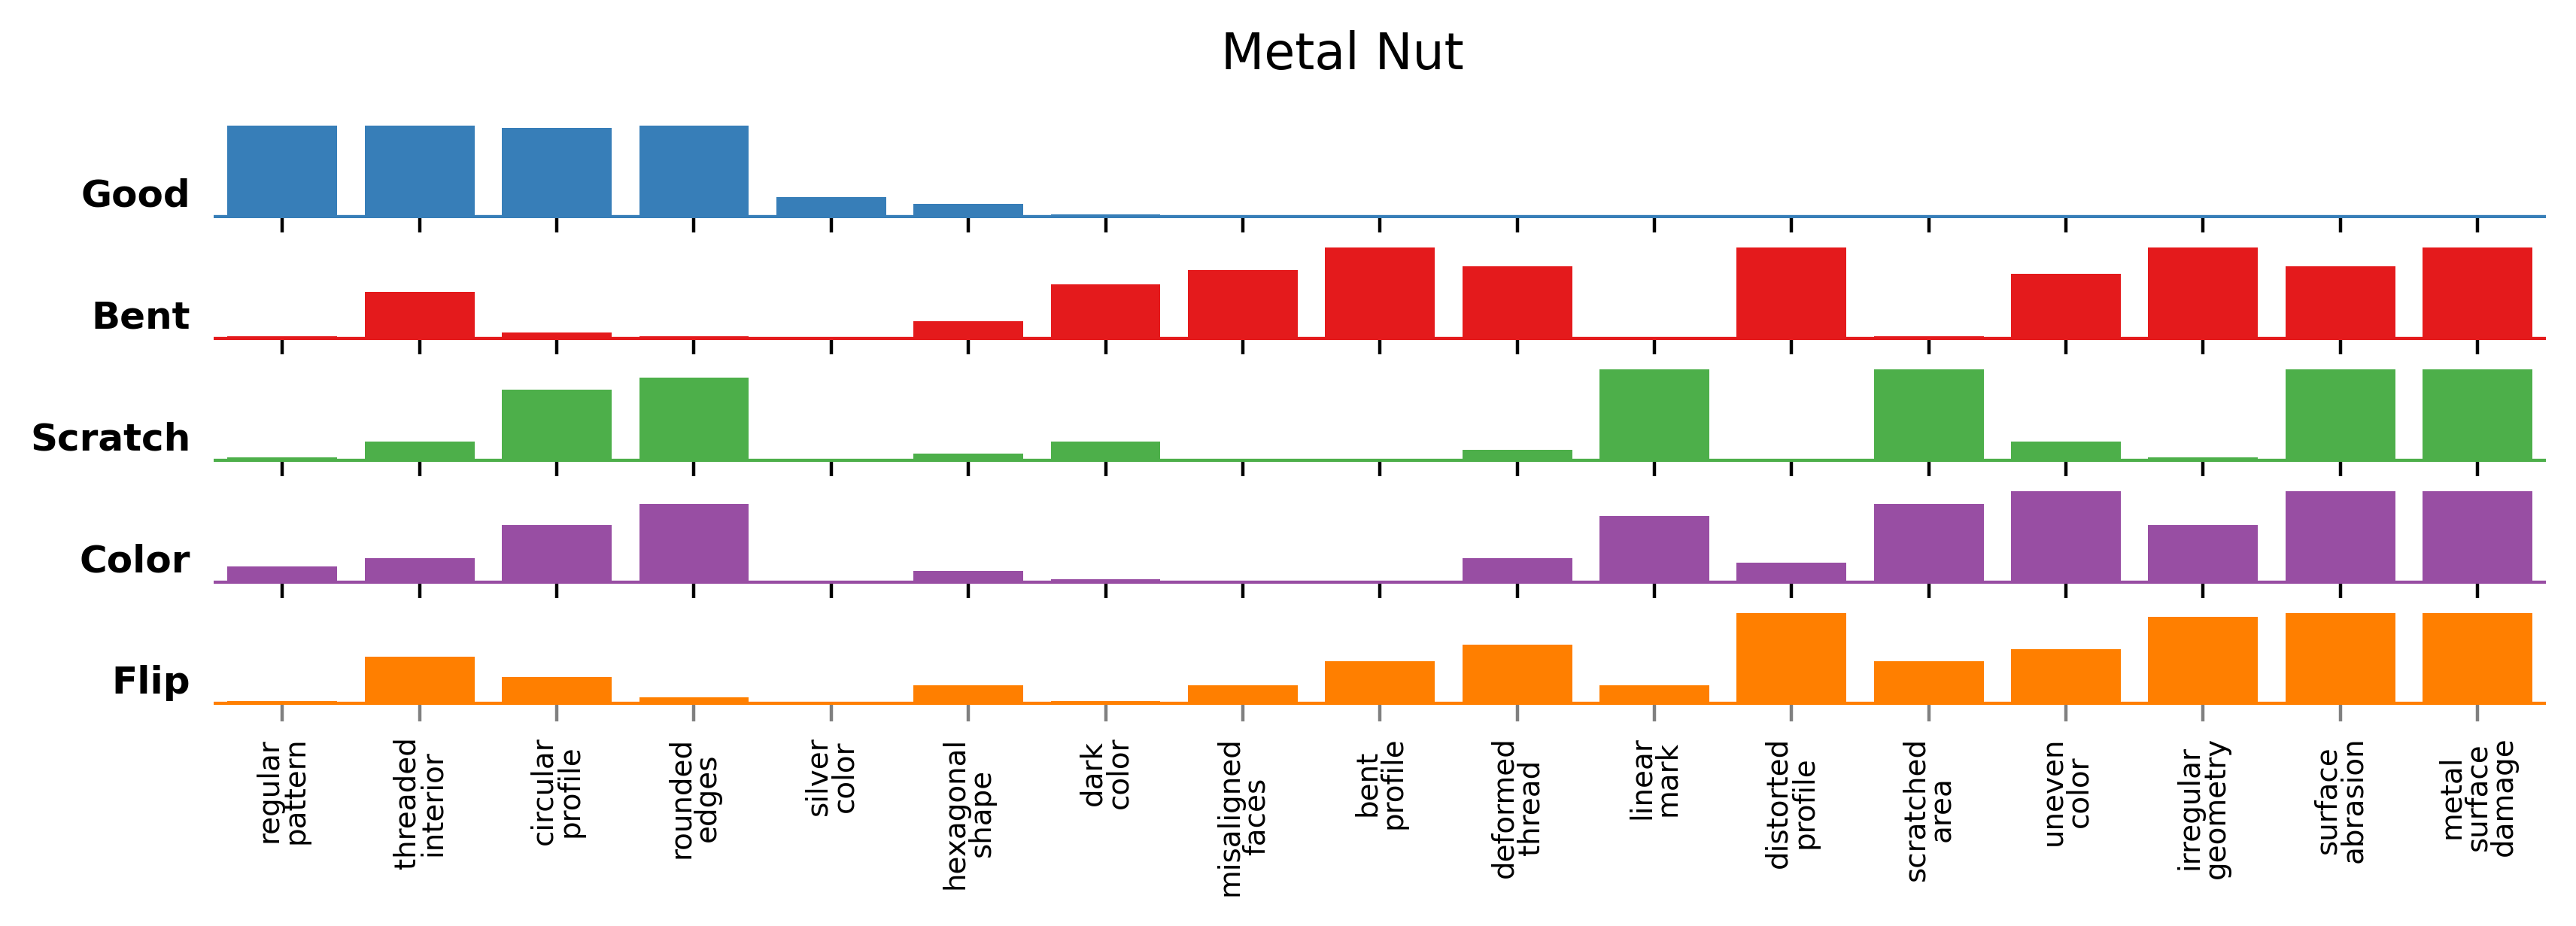

In [18]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

dataset_name = "mvtec"


paths = {
    "mvtec": [
        "capsule_dataset_automated.csv",
        "carpet_dataset_automated.csv",
        "grid_dataset_automated.csv",
        "hazelnut_dataset_automated.csv",
        "leather_dataset_automated.csv",
        "metal_nut_dataset_automated.csv",
        "pill_dataset_automated.csv",
        "screw_dataset_automated.csv",
        "tile_dataset_automated.csv",
        "toothbrush_dataset_automated.csv",
        "transistor_dataset_automated.csv",
        "wood_dataset_automated.csv",
        "zipper_dataset_automated.csv",
    ],
    "visa": [
        "candle_dataset_automated.csv",
        "capsules_dataset_automated.csv",
        "cashew_dataset_automated.csv",
        "chewinggum_dataset_automated.csv",
        "fryum_dataset_automated.csv",
        "macaroni1_dataset_automated.csv",
        "macaroni2_dataset_automated.csv",
        "pcb1_dataset_automated.csv",
        "pcb2_dataset_automated.csv",
        "pcb3_dataset_automated.csv",
        "pcb4_dataset_automated.csv",
        "pipe_fryum_dataset_automated.csv",
    ],
    "realiad": [
        "audiojack_dataset_automated.csv",
        "bottle_cap_dataset_automated.csv",
        "button_battery_dataset_automated.csv",
        "end_cap_dataset_automated.csv",
        "eraser_dataset_automated.csv",
        "fire_hood_dataset_automated.csv",
        "mint_dataset_automated.csv",
        "mounts_dataset_automated.csv",
        "pcb_dataset_automated.csv",
        "phone_battery_dataset_automated.csv",
        "plastic_nut_dataset_automated.csv",
        "plastic_plug_dataset_automated.csv",
        "porcelain_doll_dataset_automated.csv",
        "regulator_dataset_automated.csv",
        "rolled_strip_base_dataset_automated.csv",
        "sim_card_set_dataset_automated.csv",
        "switch_dataset_automated.csv",
        "tape_dataset_automated.csv",
        "terminalblock_dataset_automated.csv",
        "toothbrush_dataset_automated.csv",
        "toy_brick_dataset_automated.csv",
        "toy_dataset_automated.csv",
        "transistor1_dataset_automated.csv",
        "u_block_dataset_automated.csv",
        "usb_adaptor_dataset_automated.csv",
        "usb_dataset_automated.csv",
        "vcpill_dataset_automated.csv",
        "wooden_beads_dataset_automated.csv",
        "woodstick_dataset_automated.csv",
        "zipper_dataset_automated.csv",
    ],
}

for ps in paths[dataset_name]:
    if "metal" not in ps.lower() and "rolled" not in ps.lower():
        continue
    p = Path("cbm_data") / dataset_name / ps

    df = pd.read_csv(p)

    exclude_cols = [
        "image_path",
        "label_index",
        "mask_path",
        "split",
        "anomaly_type",
        "view",
    ]

    # compute the "normality" ranking of the concepts as the frequencies of good
    # and the abnormality is the frequencies of all other types of anomalies

    translate = {"mvtec": "good", "visa": "normal", "realiad": "good"}

    def get_frequencies(df, anomaly_type=translate[dataset_name]):
        df_good = df[df["anomaly_type"] == anomaly_type]
        frequencies = {}
        for col in df_good.columns:
            if col not in exclude_cols:
                frequencies[col] = df_good[col].value_counts()

        # normalize the frequencies to get percentages
        for col in frequencies:
            frequencies[col] = frequencies[col] / frequencies[col].sum() * 100
        return frequencies

    good_frequencies = get_frequencies(df, anomaly_type=translate[dataset_name])

    list_freqs = []
    for anomaly_type in df["anomaly_type"].unique():
        if anomaly_type == translate[dataset_name]:
            continue
        freqs = get_frequencies(df, anomaly_type=anomaly_type)
        list_freqs.append((anomaly_type, freqs))

    # aggregate the frequencies of all the anomaly types into a single dictionary
    anomaly_frequencies = {}
    for anomaly_type, freqs in list_freqs:
        for col in freqs:
            if col not in anomaly_frequencies:
                anomaly_frequencies[col] = {}
            for val in freqs[col].index:
                if val not in anomaly_frequencies[col]:
                    anomaly_frequencies[col][val] = 0.0
                anomaly_frequencies[col][val] += freqs[col][val] / len(list_freqs)

    # list the concepts in order of normality and abnormality
    concepts = []
    for col in good_frequencies:
        concepts.append(
            (
                col,
                good_frequencies[col].get(1, 0.0),
                anomaly_frequencies[col].get(1, 0.0),
            )
        )

    concepts.sort(key=lambda x: x[1] - x[2], reverse=True)

    # barplot of that
    # concepts_df = pd.DataFrame(concepts, columns=["concept", "normality", "abnormality"])
    # concepts_df.plot(x="concept", y=["normality", "abnormality"], kind="bar", figsize=(10, 5))
    # plt.title("Concept Normality and Abnormality")
    # plt.ylabel("Percentage")
    # plt.xlabel("Concept")
    # plt.xticks(rotation=45)
    # plt.legend(loc="upper right")
    # plt.tight_layout()
    # plt.show()

    # ── Config ──
    MODE = "discrete"  # "discrete" or "kde"
    DPI = 400
    ROW_HEIGHT = 0.2  # inches per row
    ASPECT = 12  # width = ASPECT * ROW_HEIGHT
    OVERLAP = -0.1  # fraction of row height to overlap (0 = none, 1 = full)
    KDE_SIGMA = 1.5  # gaussian smoothing sigma for kde mode
    BAR_WIDTH = 0.8
    Y_MAX = 120  # cap the y-axis to control bar height

    # ── Data ──
    col_order = [c[0] for c in concepts]
    n_concepts = len(col_order)
    x = np.arange(n_concepts)

    all_types = list(df["anomaly_type"].unique())
    n_types = len(all_types)
    breakpoint()
    all_types.remove(translate[dataset_name])
    all_types = [translate[dataset_name]] + all_types

    freq_data = {}
    for t in all_types:
        freqs = get_frequencies(df, anomaly_type=t)
        freq_data[t] = np.array(
            [freqs[c].get(1, 0.0) if c in freqs else 0.0 for c in col_order]
        )

    # ── Colors ── (cycle through the 8 Set1 colors)
    cmap = plt.get_cmap("Set1")
    ordering = {i: i for i in range(n_types)}
    ordering[0] = 1
    ordering[1] = 0
    colors = [cmap((ordering[i]) % 8) for i in range(n_types)]

    # ── Figure ──
    fig_w = 10
    fig_h = ROW_HEIGHT * (n_types * (1 - OVERLAP) + OVERLAP) + 1.5  # extra for x labels
    fig, axes = plt.subplots(n_types, 1, figsize=(fig_w, fig_h), sharex=True, dpi=DPI)
    if n_types == 1:
        axes = [axes]

    fig.subplots_adjust(hspace=-OVERLAP)

    for i, (ax, t) in enumerate(zip(axes, all_types)):
        vals = freq_data[t]
        color = colors[i]

        if MODE == "kde":
            y_smooth = gaussian_filter1d(vals, sigma=KDE_SIGMA)
            ax.fill_between(x, 0, y_smooth, color=color, alpha=1, linewidth=0)
            ax.plot(x, y_smooth, color="white", linewidth=1.5)
        else:
            ax.bar(x, vals, width=BAR_WIDTH, color=color, edgecolor="none", linewidth=0)

        ax.axhline(0, color=color, linewidth=1.5)
        ax.set_ylim(0, Y_MAX)

        # Label
        ax.text(
            -0.01,
            0.2,
            t.replace("_", " ").title(),
            fontweight="bold",
            color="black",
            ha="right",
            va="center",
            transform=ax.transAxes,
            fontsize=9,
        )

        # Clean up
        ax.set_yticks([])
        ax.set_ylabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.patch.set_alpha(0)
        ax.set_xlim(-0.5, n_concepts - 0.5)

    # X-tick labels on bottom (replace spaces with newlines, add small ticks)
    tick_labels = [c.replace(" ", "\n").replace("_", "\n").lower() for c in col_order]
    bottom_ax = axes[-1]
    bottom_ax.set_xticks(x)
    bottom_ax.set_xticklabels(
        tick_labels, rotation=90, fontsize=7, color="black", linespacing=0.9
    )
    bottom_ax.tick_params(
        axis="x",
        which="major",
        length=4,
        width=0.8,
        color="grey",
        direction="out",
        bottom=True,
    )

    fig.patch.set_facecolor("white")
    # plt.title(f"{ps.split('_')[0].title()}", fontsize=12)
    # set the suptitle of the first plot to the dataset name
    ps = ps.split('_')[0]
    ps = "Metal Nut" if ps.lower() == "metal" else ps
    ps = "Rolled Strip Base" if ps.lower() == "rolled" else ps
    plt.suptitle(f"{ps.title()}", fontsize=12)
    plt.savefig("ridge_plot_mpl.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
